In [1]:
import torch
import torch.nn as nn
from torch.nn.functional import relu
from torch.nn.modules.padding import ReplicationPad2d
import rasterio
#import numpy as np
import os
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.__version__)
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

3.10.8


In [45]:
# --- Cell 2: The Model Architecture ---
# siamese unet
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class LocalizationDecoder(nn.Module):
    def __init__(self,n_channels=3, n_classes=1):
        super().__init__()
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, 1)
    def forward(self, skips):
        s1, s2, s3, s4 = skips
        x = self.up1(s4)
        #print(f"Shape after up1: {x.shape}")  # Debug print to check the shape after upsampling at the bottleneck
        x = self.conv_up1(torch.cat([x, s3], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up1: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 3
        x = self.up2(x)
        #print(f"Shape after up2: {x.shape}")  # Debug print to check the shape after upsampling at decoder stage 2
        x = self.conv_up2(torch.cat([x, s2], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up2: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 2
        x = self.up3(x)
        #print(f"Shape after up3: {x.shape}")  # Debug print to check the shape after upsampling at decoder stage 1
        x = self.conv_up3(torch.cat([x, s1], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up3: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 1
        return self.outc(x)  # Return raw logits for multi-class segmentation with F.cross_entropy.
        


class DamageDecoder(nn.Module):
    def __init__(self,n_channels=3, n_classes=1):
        super().__init__()
        self.fuse4 = nn.Conv2d(1024, 512, 1)  # Fuse features from both branches at the bottleneck
        self.fuse3 = nn.Conv2d(512, 256, 1)   # Fuse features from both branches at the decoder stage 3
        self.fuse2 = nn.Conv2d(256, 128, 1)   # Fuse features from both branches at the decoder stage 2
        self.fuse1 = nn.Conv2d(128, 64, 1)    # Fuse features from both branches at the decoder stage 1

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.outc = nn.Conv2d(64, n_classes, 1)
    def forward(self, skips_pre, skips_post):
        x1a, x2a, x3a, x4a = skips_pre
        x1b, x2b, x3b, x4b = skips_post

        #decoder
        s4 = self.fuse4(torch.cat([x4a, x4b], dim=1))  # Fuse features from both branches at the bottleneck
        #print(f"Shape after fuse4: {s4.shape}")  # Debug print to check the shape after fusion at the bottleneck
        s3 = self.fuse3(torch.cat([x3a, x3b], dim=1))  # Fuse features from both branches at the decoder stage 3
        #print(f"Shape after fuse3: {s3.shape}")  
        s2 = self.fuse2(torch.cat([x2a, x2b], dim=1))  # Fuse features from both branches at the decoder stage 2
        #print(f"Shape after fuse2: {s2.shape}")  
        s1 = self.fuse1(torch.cat([x1a, x1b], dim=1))  # Fuse features from both branches at the decoder stage 1
        #print(f"Shape after fuse1: {s1.shape}")  

        x = self.up1(s4)
        #print(f"Shape after up1: {x.shape}")  # Debug print to check the shape after upsampling at the bottleneck
        x = self.conv_up1(torch.cat([x, s3], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up1: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 3
        x = self.up2(x)
        #print(f"Shape after up2: {x.shape}")  # Debug print to check the shape after upsampling at decoder stage 2
        x = self.conv_up2(torch.cat([x, s2], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up2: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 2
        x = self.up3(x)
        #print(f"Shape after up3: {x.shape}")  # Debug print to check the shape after upsampling at decoder stage 1
        x = self.conv_up3(torch.cat([x, s1], dim=1))  # Skip connections are key!
        #print(f"Shape after conv_up3: {x.shape}")  # Debug print to check the shape after convolution at decoder stage 1
        return self.outc(x)  # Return raw logits for multi-class segmentation with F.cross_entropy.
        



class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=4):
        super().__init__()
        self.inc1a = DoubleConv(n_channels, 64)
        self.inc1b = DoubleConv(n_channels, 64)
        self.down1a = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down1b = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2a = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down2b = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3a = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down3b = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.localization_decoder = LocalizationDecoder(n_channels, n_classes)
        self.damage_decoder = DamageDecoder(n_channels, n_classes)
    def forward_damage(self, xa, xb):
        #encoder for a
        x1a = self.inc1a(xa)
        x2a = self.down1a(x1a)
        x3a = self.down2a(x2a)
        x4a = self.down3a(x3a)

        #encoder for b
        x1b = self.inc1b(xb)
        x2b = self.down1b(x1b)
        x3b = self.down2b(x2b)
        x4b = self.down3b(x3b)

        return self.damage_decoder((x1a, x2a, x3a, x4a), (x1b, x2b, x3b, x4b))  # Return raw logits for multi-class segmentation with F.cross_entropy.

    def forward_localization(self, xa):
        #encoder for a
        x1a = self.inc1a(xa)
        x2a = self.down1a(x1a)
        x3a = self.down2a(x2a)
        x4a = self.down3a(x3a)

        return self.localization_decoder((x1a, x2a, x3a, x4a))  # Return raw logits for multi-class segmentation with F.cross_entropy.
    
    def forward(self, xa, xb):
        if xb is None:
            return self.forward_localization(xa)
        else:
            return self.forward_damage(xa, xb)

In [3]:
# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 0 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 0

    return mask_np.astype(np.int64) # Masks are typically integer class labels

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)


def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

In [46]:
def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('loss_value') # Changed from dice_coef as it's now total loss
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks, is_prediction=False, threshold = 0.5):
    # Define colors for remapped classes (0:No Damage, 1:Minor, 2:Major, 3:Destroyed)
    # Original class 0 ('un-classified') will be ignored (value 255) and visualized as black.
    class_colors = np.array([
        [0, 255, 0],    # Green (Remapped class 0: No Damage)
        [255, 255, 0],  # Yellow (Remapped class 1: Minor Damage)
        [255, 165, 0],  # Orange (Remapped class 2: Major Damage)
        [255, 0, 0]     # Red (Remapped class 3: Destroyed)
    ], dtype=np.uint8)

    # Ensure masks is numpy array
    if isinstance(masks, torch.Tensor):
        masks = masks.cpu().numpy()

    if is_prediction: # Input is (C, H, W) probabilities\
      colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
      channels, height, width = masks.shape

      for y in range(height):
          for x in range(width):
              selected_colors = class_colors[masks[:,y,x] > threshold]

              if len(selected_colors) > 0:
                  colorimg[y,x,:] = np.mean(selected_colors, axis=0)

      return colorimg.astype(np.uint8)
    else: # Input is (H, W) integer class labels (0, 1, 2, 3 or 255 for ignore)
        if masks.ndim != 2:
            raise ValueError("Ground truth masks must be (H, W) for visualization.")
            print(masks.shape)

        class_labels = masks # This will be the (H, W) array
        height, width = class_labels.shape
        colorimg = np.zeros((height, width, 3), dtype=np.uint8) # Start with black (for ignored pixels)

        for class_idx in range(4): # Loop through 0, 1, 2, 3
            mask_condition = (class_labels == class_idx)
            colorimg[mask_condition] = class_colors[class_idx]
        # Pixels with IGNORE_INDEX (255) will remain black (0,0,0), which is fine.

        return colorimg

Dataloaders

In [59]:
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms
import rasterio
import numpy as np

class TrainingDataset(Dataset):
    def __init__(self, pre_image_paths, post_image_paths, label_paths, is_damage = False, transform=None, num_classes=4): # num_classes should be 4 for multi-class
        self.pre_image_paths = pre_image_paths
        self.post_image_paths = post_image_paths
        self.label_paths = label_paths
        self.is_damage = is_damage
        self.transform = transform # This transform is for images
        self.num_classes = num_classes # Now reflects actual number of classes
        print("TrainingDataset initialized for multi-class (4 damage levels).")

    def __len__(self):
        return len(self.pre_image_paths)

    def __getitem__(self, index):
        # Load image as NumPy array (C, H, W, float32) using the provided function
        pre_image_np = load_and_preprocess(self.pre_image_paths[index])
        if(self.is_damage):
            post_image_np = load_and_preprocess(self.post_image_paths[index])

        # Load mask as NumPy array (1, H, W, int64) using the new helper function
        mask_np_raw = load_raw_mask(self.label_paths[index]) # Should contain 0, 1, 2, 3, 4

        # Convert image_np (C, H, W) to a PIL Image (H, W, C) for torchvision transforms
        # which expect PIL Image for operations like Resize
        if pre_image_np.shape[0] == 3: # Assuming RGB
            # Multiply by 255 and convert to uint8 before creating PIL Image
            image_pil = Image.fromarray((pre_image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
        elif pre_image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
            # Select the first 3 channels (R, G, B) and transpose for PIL
            image_pil = Image.fromarray((pre_image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))

        elif pre_image_np.shape[0] == 1: # Assuming grayscale
            image_pil = Image.fromarray((pre_image_np.squeeze(0) * 255).astype(np.uint8))
        else:
            raise ValueError(f"Unsupported pre image channel count: {pre_image_np.shape[0]} for PIL conversion")
        
        if(self.is_damage):
            if post_image_np.shape[0] == 3: # Assuming RGB
                # Multiply by 255 and convert to uint8 before creating PIL Image
                post_image_pil = Image.fromarray((post_image_np.transpose(1, 2, 0) * 255).astype(np.uint8))
            elif post_image_np.shape[0] == 4: # Assuming RGB-NIR, take only RGB
                # Select the first 3 channels (R, G, B) and transpose for PIL
                post_image_pil = Image.fromarray((post_image_np[:3, :, :].transpose(1, 2, 0) * 255).astype(np.uint8))
            elif post_image_np.shape[0] == 1: # Assuming grayscale
                post_image_pil = Image.fromarray((post_image_np.squeeze(0) * 255).astype(np.uint8))
            else:
                raise ValueError(f"Unsupported post image channel count: {post_image_np.shape[0]} for PIL conversion")

        # Apply the image transform (includes Resize, ToTensor, Normalize)
        if self.transform:
            pre_image_tensor = self.transform(image_pil)
            if(self.is_damage):
                post_image_tensor = self.transform(post_image_pil)
        else:
            # If no transform is provided, at least convert to tensor
            pre_image_tensor = transforms.ToTensor()(image_pil)
            if(self.is_damage):
                post_image_tensor = transforms.ToTensor()(post_image_pil)

        # Determine the target size for the mask from the transformed image
        target_size = pre_image_tensor.shape[-2:] # Get (H, W) from the pre-image tensor

        # Convert raw mask (1, H, W) to PyTorch Tensor (float32). Keep as float for resizing.
        mask_tensor = torch.from_numpy(mask_np_raw).float()

        # Probably don't need resize because the masks are already cropped to the right size?
        # Ensure mask_tensor is (C, H, W) for Resize, then (1, H, W) float
        #mask_resized = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
        #    mask_tensor
        #)

        # The mask will be [1, H, W] float with original integer class values (0,1,2,3,4)
        if(self.is_damage):
            return pre_image_tensor, post_image_tensor, mask_tensor
        else:
            return pre_image_tensor, mask_tensor

print("TrainingDataset class defined .")

TrainingDataset class defined .


In [55]:
import os
import glob
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import numpy as np

def get_data_loaders(batch_size=4, subset_size=None, is_damage=False, path = '/Users/yujiewu/SP/haiti_cropped_smaller'):
    base_path = path
    post_image_dir = os.path.join(base_path, 'images')
    pre_image_dir = os.path.join(base_path, 'images-pre-disaster')
    post_label_dir = os.path.join(base_path, 'labels')
    pre_label_dir = os.path.join(base_path, 'labels-pre-disaster')

    all_post_image_paths = sorted(glob.glob(os.path.join(post_image_dir, '*.tif')))
    all_pre_image_paths = sorted(glob.glob(os.path.join(pre_image_dir, '*.tif')))
    all_post_label_paths = sorted(glob.glob(os.path.join(post_label_dir, '*.tif')))
    all_pre_label_paths = sorted(glob.glob(os.path.join(pre_label_dir, '*.tif')))

    if len(all_post_image_paths) != len(all_post_label_paths):
        raise ValueError("Mismatch between number of post images and labels.")

    if len(all_pre_image_paths) != len(all_pre_label_paths):
        raise ValueError("Mismatch between number of pre images and labels.")
    
    if len(all_pre_label_paths) != len(all_post_label_paths):
        raise ValueError("Mismatch between number of pre labels and labels.")


    # Pair image and label paths
    if is_damage:
        all_pairs = list(zip(all_post_image_paths, all_pre_image_paths, all_post_label_paths))
    else:
        all_pairs = list(zip(all_pre_image_paths, all_pre_label_paths)) # For localization, we only use pre-disaster images and labels (labels are the same for both branches but only pre branch is used)
    
    # Split all pairs into training and validation sets
    train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

    # --- Undersampling for the training set --- (not doing, code is on colab if needed) 

    if subset_size is not None:
        final_train_pairs = train_pairs[:subset_size]#final_train_pairs[:subset_size]
        val_pairs = val_pairs[:subset_size // 4] # Keep validation subset smaller if train is subsetted
    #else:
    #  val_pairs = val_pairs[:len(final_train_pairs) // 4]
    if is_damage:
        train_post_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
        train_pre_image_paths = [p[1] for p in train_pairs]#final_train_pairs]
        train_label_paths = [p[2] for p in train_pairs]#final_train_pairs]

        val_post_image_paths = [p[0] for p in val_pairs]
        val_pre_image_paths = [p[1] for p in val_pairs]
        val_label_paths = [p[2] for p in val_pairs]
    else:
        train_pre_image_paths = [p[0] for p in train_pairs]#final_train_pairs]
        train_label_paths = [p[1] for p in train_pairs]#final_train_pairs]
        train_post_image_paths = None

        val_pre_image_paths = [p[0] for p in val_pairs]
        val_label_paths = [p[1] for p in val_pairs]
        val_post_image_paths = None

    print(f"Training images (using pre-undersampled drive): {len(train_pre_image_paths)}")
    print(f"Validation images: {len(val_pre_image_paths)}")

    # Define image transformations
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    image_size = (256, 256) # Define target image size, further reduced for faster verification
    #print(f"get_data_loaders: Setting image_size to {image_size}")

    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    val_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    train_dataset = TrainingDataset(
        pre_image_paths=train_pre_image_paths,
        post_image_paths = train_post_image_paths,
        label_paths=train_label_paths,
        is_damage=is_damage,
        transform=train_transform
    )

    val_dataset = TrainingDataset(
        pre_image_paths=val_pre_image_paths,
        post_image_paths = val_post_image_paths,
        label_paths=val_label_paths,
        is_damage=is_damage,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        drop_last=True # Add drop_last=True here
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        drop_last=True # Add drop_last=True here
    )

    return {'train': train_loader, 'val': val_loader}

print("Function `get_data_loaders` defined with undersampling capability.")


Function `get_data_loaders` defined with undersampling capability.


In [69]:
def process_mask_for_cross_entropy(mask_tensor, target_size, num_output_classes, ignore_index=255):
    # mask_tensor: (1, H_orig, W_orig) with values 0, 1, 2, 3, 4
    # num_output_classes: 4 (for no-damage, minor, major, destroyed)

    # Create an empty tensor for remapped labels, filled with ignore_index
    # Use torch.full_like for creating a tensor with the same properties as mask_tensor
    remapped_labels = torch.full(mask_tensor.shape, fill_value=ignore_index, dtype=torch.long, device=mask_tensor.device)

    # Remap original labels (1, 2, 3, 4) to new labels (0, 1, 2, 3)
    # Original 0 ('un-classified') will remain `ignore_index`
    for original_val in range(1, 5): # Iterate through original classes 1 ('no-damage') to 4 ('destroyed')
        new_val = original_val - 1 # New classes 0 to 3
        remapped_labels[mask_tensor == original_val] = new_val

    # Resize the remapped labels to the target_size
    # Squeeze and unsqueeze are used to handle the channel dimension for transforms.Resize
    resized_labels_with_channel = transforms.Resize(target_size, interpolation=transforms.InterpolationMode.NEAREST)(
        remapped_labels.squeeze(0).unsqueeze(0) # (H_orig, W_orig) -> (1, H_orig, W_orig) -> (1, H_new, W_new)
    )
    return resized_labels_with_channel.squeeze(0) # Returns (H_new, W_new) tensor with integer class labels

def remap_labels(mask_tensor, ignore_index=255):
    # mask_tensor: (1, H, W) with values 0, 1, 2, 3, 4
    # Create an empty tensor for remapped labels, filled with ignore_index
    remapped_labels = torch.full(mask_tensor.shape, fill_value=ignore_index, dtype=torch.long, device=mask_tensor.device)

    # Remap original labels (1, 2, 3, 4) to new labels (0, 1, 2, 3)
    # Original 0 ('un-classified') will remain `ignore_index`
    for original_val in range(1, 5): # Iterate through original classes 1 ('no-damage') to 4 ('destroyed')
        new_val = original_val - 1 # New classes 0 to 3
        remapped_labels[mask_tensor == original_val] = new_val

    return remapped_labels.squeeze(0) # Returns (H, W) tensor with integer class labels

def calc_loss(pred, target, metrics, class_weights=None, ignore_index = 255):
  device = pred.device

  # Handle class weights
  if class_weights is not None:
      if not isinstance(class_weights, torch.Tensor):
          class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
      class_weights = class_weights.to(device)

  # Cross-Entropy Loss
  # F.cross_entropy expects input (N, C, H, W) and target (N, H, W)
  # It applies softmax implicitly on the input logits.
  # Squeeze the target to remove the channel dimension (1, H, W) -> (H, W)
  ce_loss = F.cross_entropy(pred, target.squeeze(1), weight=class_weights, ignore_index=ignore_index, reduction='mean')

  # Update metrics
  metrics['loss'] += ce_loss.item() * target.size(0) # target.size(0) is batch size
  # We can add accuracy or other metrics if desired, but for now, just loss.

  return ce_loss

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs)))


def train_damage_model(model, optimizer, scheduler, num_epochs=25, subset_size=None, pos_weight=None): # pos_weight is now unused
    dataloaders = get_data_loaders(subset_size=subset_size, is_damage = True) # Passed subset_size to get_data_loaders
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    # Initialize dictionaries to store metrics for plotting
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for pre_images, post_images, labels in dataloaders[phase]:
                pre_images = pre_images.to(device)
                post_images = post_images.to(device)
                labels = labels.to(device) # labels are [N, 1, H, W] float with original integer class values

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(pre_images, post_images) # outputs will be [N, 4, H, W] logits
                    # Process labels to get [N, H, W] long integer class labels for cross_entropy
                    processed_target = process_mask_for_cross_entropy(labels, (labels.size()[2], labels.size()[3]), 4, ignore_index=255)
                    loss = calc_loss(outputs, processed_target, metrics) # pos_weight removed

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                epoch_samples += pre_images.size(0)

            # Move scheduler.step() after optimizer.step() if it's based on epoch validation loss
            # Otherwise, it might be inside the train loop for each batch or after train phase
            if phase == 'train': # Generally, scheduler steps after a training epoch
                scheduler.step()

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            epoch_ce = metrics['ce'] / epoch_samples # Changed from bce
            epoch_dice = metrics['dice'] / epoch_samples

            # Store metrics in history
            history[f'{phase}_loss'].append(epoch_loss)
            #history[f'{phase}_ce'].append(epoch_ce) # Changed from bce
            #history[f'{phase}_dice'].append(epoch_dice)

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [79]:
def dice_loss(pred, target, smooth=1.):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=2).sum(dim=2)

    loss = (1 - ((2. * intersection + smooth) / (pred.sum(dim=2).sum(dim=2) + target.sum(dim=2).sum(dim=2) + smooth)))

    return loss

def calc_loss_localization(pred, target, metrics, bce_weight=0.5, pos_weight=None):
    # Ensure pos_weight is on the correct device if provided
    if pos_weight is not None:
        pos_weight = pos_weight.to(pred.device)
        bce = F.binary_cross_entropy_with_logits(pred, target, pos_weight=pos_weight)
    else:
        bce = F.binary_cross_entropy_with_logits(pred, target)

    # Apply sigmoid for Dice loss calculation
    pred_sigmoid = torch.sigmoid(pred)
    # dice_loss returns a tensor of shape (N, 1) where each element is (1 - Dice_score)
    dice_per_sample = dice_loss(pred_sigmoid, target)

    # For Dice loss, typically mean over samples is taken.
    weighted_dice = dice_per_sample.mean()

    loss = bce * bce_weight + weighted_dice * (1 - bce_weight)

    metrics['bce'] += bce.data.cpu().numpy() * target.size(0)
    metrics['dice'] += weighted_dice.data.cpu().numpy() * target.size(0)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss

def train_localization_model(model, optimizer, scheduler, num_epochs=25, subset_size=None, pos_weight=None): # pos_weight is now unused
    dataloaders = get_data_loaders(subset_size=subset_size) # Passed subset_size to get_data_loaders
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    # Initialize dictionaries to store metrics for plotting
    history = defaultdict(list)

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            for pre_inputs, labels in dataloaders[phase]:
                pre_inputs = pre_inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(pre_inputs, None)
                    loss = calc_loss_localization(outputs, labels, metrics, pos_weight=pos_weight) # Pass pos_weight

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        # Move scheduler.step() after optimizer.step()

                # statistics
                epoch_samples += pre_inputs.size(0)

            scheduler.step()

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples
            epoch_bce = metrics['bce'] / epoch_samples
            epoch_dice = metrics['dice'] / epoch_samples

            # Store metrics in history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_bce'].append(epoch_bce)
            history[f'{phase}_dice'].append(epoch_dice)

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, history
            

In [19]:
import torch

# Explicitly call get_data_loaders to ensure it uses the latest definitions
dataloaders = get_data_loaders(batch_size=4, path = "/Users/yujiewu/SP/haiti_cropped_smaller/")

# Get the first batch of images and labels
pre_inputs, post_inputs, labels = next(iter(dataloaders['train']))

# Print the shape of the inputs (images)
print(f"Shape of pre-images in the batch: {pre_inputs.shape}")
print(f"Shape of post-images in the batch: {post_inputs.shape}")

# Expected shape: [batch_size, channels, height, width]
# For 256x256 images and batch_size=4, this should be torch.Size([4, 3, 256, 256])

Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
Shape of pre-images in the batch: torch.Size([4, 3, 256, 256])
Shape of post-images in the batch: torch.Size([4, 3, 256, 256])


2026-04-02 00:08:17.609581-07:00
Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
Epoch 0/29
----------
train: bce: 0.515510, dice: 0.373784, loss: 0.444647
val: bce: 0.760966, dice: 0.327882, loss: 0.544424
saving best model
5m 44s
Epoch 1/29
----------
train: bce: 0.447156, dice: 0.322890, loss: 0.385023
val: bce: 0.382900, dice: 0.311853, loss: 0.347376
saving best model
3m 57s
Epoch 2/29
----------
train: bce: 0.416682, dice: 0.313526, loss: 0.365104
val: bce: 0.393859, dice: 0.302403, loss: 0.348131
3m 39s
Epoch 3/29
----------
train: bce: 0.394470, dice: 0.296312, loss: 0.345391
val: bce: 0.313575, dice: 0.297178, loss: 0.305377
saving best model
3m 48s
Epoch 4/29
----------
train: bce: 0.382258, dice: 0.286432, loss: 0.334345
val: bce: 0.509467, dice: 0.283188, loss: 0.396327
13m 22s
Epoch 5/29
----------
train: bce: 0.373505, dic

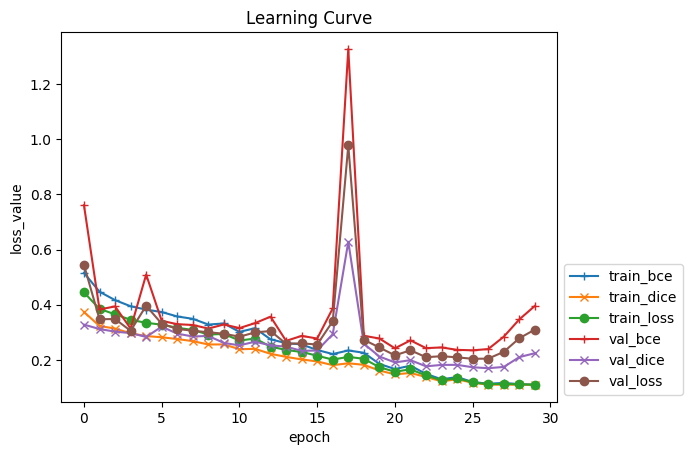

In [ ]:
IGNORE_INDEX = 255
num_class = 1 #for localization its 1
num_class_damage = 4 # Set num_class to 4 for damage level assessment (undestroyed, minor, major, destroyed)
num_epochs_localization = 30 # one epoch is 2-3 min

from datetime import datetime
from zoneinfo import ZoneInfo

# Get the current time in a specific timezone (e.g., 'US/Pacific')
tz = ZoneInfo('US/Pacific')
current_time_tz = datetime.now(tz);

# Print the timezone-aware time
print(current_time_tz);
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# For multi-class segmentation with F.cross_entropy, a single pos_weight is not directly applicable.
# If class weighting is desired for F.cross_entropy, a `weight` tensor (one value per class) should be used.
# For now, `pos_weight` is removed from `train_model` call, implying unweighted classes for CE.
# The previous `pos_weight` calculation was for binary BCE and is not needed here.
model = UNet(n_channels=3, n_classes=num_class).to(device) #localization first
optimizer_s1  = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=1e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_s1, step_size=60, gamma=0.1)
model, history_s1 = train_localization_model(model, optimizer_s1, exp_lr_scheduler, num_epochs=num_epochs_localization, subset_size = 1600, pos_weight=None)
torch.save(model.state_dict(), '/Users/yujiewu/SP/model-saves/unet_model_siamese_localization.pth')

print("Finished training localization model. Starting damage level assessment training...")

plot_errors(history_s1, 'Learning Curve')

Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
Epoch 0/29
----------
train: loss: 1.287063
val: loss: 1.814907
saving best model
122m 35s
Epoch 1/29
----------
train: loss: 1.245046
val: loss: 1.269677
saving best model
51m 42s
Epoch 2/29
----------
train: loss: 1.197634
val: loss: 1.209981
saving best model
2m 36s
Epoch 3/29
----------
train: loss: 1.173422
val: loss: 1.465885
2m 39s
Epoch 4/29
----------
train: loss: 1.166711
val: loss: 1.248418
2m 27s
Epoch 5/29
----------
train: loss: 1.135691
val: loss: 1.470669
2m 18s
Epoch 6/29
----------
train: loss: 1.152485
val: loss: 1.168369
saving best model
2m 37s
Epoch 7/29
----------
train: loss: 1.123932
val: loss: 1.154916
saving best model
2m 32s
Epoch 8/29
----------
train: loss: 1.116151
val: loss: 1.196122
2m 35s
Epoch 9/29
----------
train: loss: 1.129963
val: loss: 1.236796
2m 2

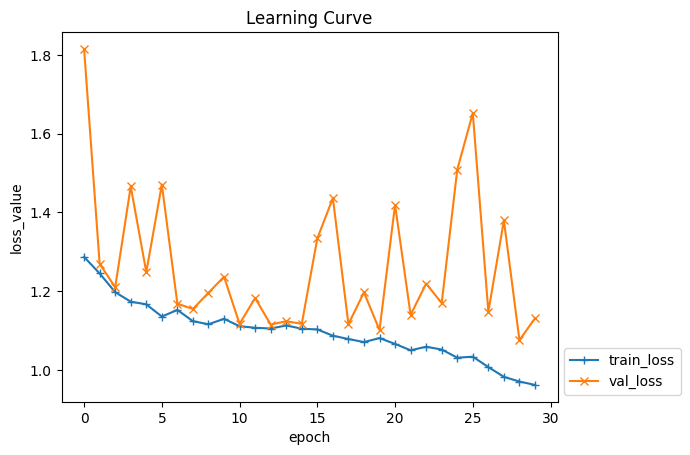

Training images (using pre-undersampled drive): 281
Validation images: 3
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
Prediction probabilities shape: (4, 4, 256, 256)


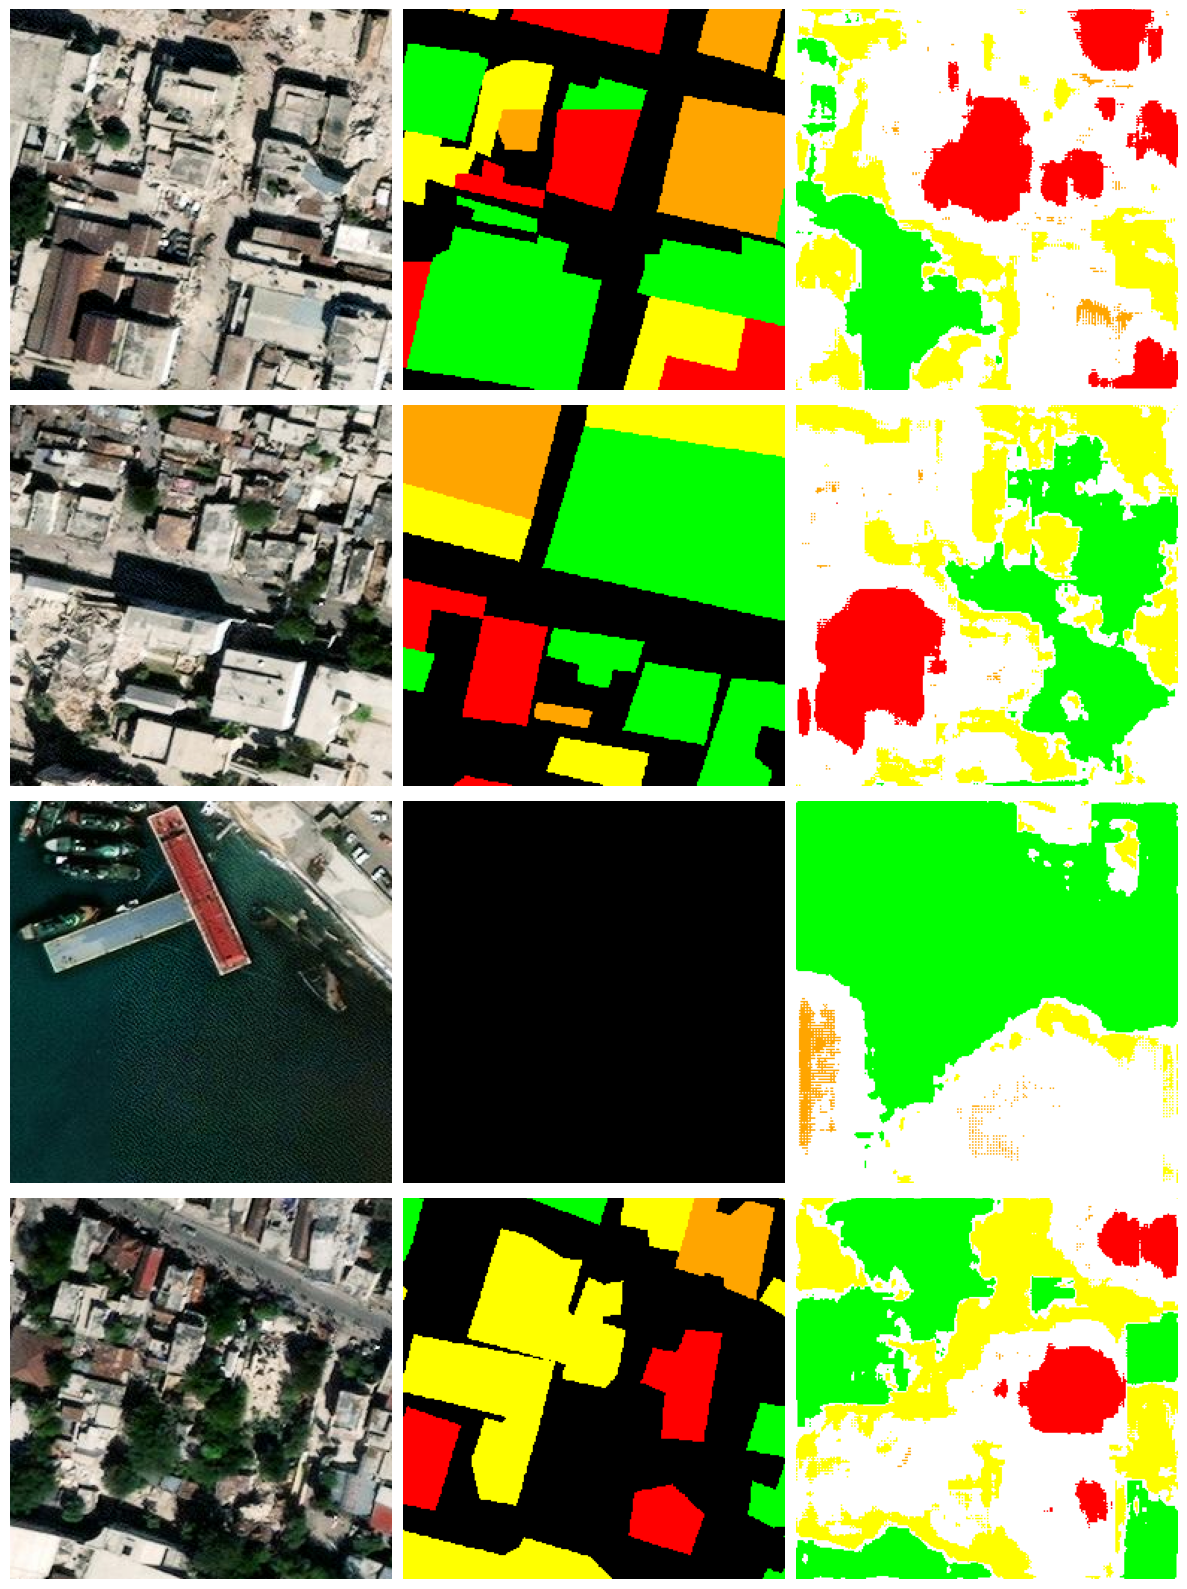

In [85]:
#the damage model (run after running previous cell)
num_epochs_damage = 30 # one epoch is 2-3 min

model = UNet(n_classes=num_class_damage).to(device)
#model.load_state_dict(torch.load('/Users/yujiewu/SP/model-saves/unet-detect-house.pth', weights_only=True))
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=60, gamma=0.1)

# Pass pos_weight=None as calc_loss no longer uses it directly
model, history = train_damage_model(model, optimizer_ft, exp_lr_scheduler, num_epochs=num_epochs_damage, subset_size = 1600, pos_weight=None)
torch.save(model.state_dict(), '/Users/yujiewu/SP/model-saves/unet_model_siamese.pth')

# Plot learning curves
plot_errors(history, 'Learning Curve')

model.eval()  # Set model to the evaluation mode
# Re-initialize dataloaders for testing/visualization, also with the small subset
test_dataloaders = get_data_loaders(batch_size=3, subset_size=15) # Get 3 samples for plotting from the small subset
test_loader = test_dataloaders['val'] # Use the validation set as test set for visualization

# Get the first batch
pre_inputs = pre_inputs.to(device)
post_inputs = post_inputs.to(device)
labels = labels.to(device) # labels are [N, 1, H, W] float with original integer class values (0,1,2,3,4)

# Predict
with torch.no_grad():
    pred_logits = model(pre_inputs, post_inputs) # model outputs logits: [N, 4, H, W]
    pred_probs = F.softmax(pred_logits, dim=1) # Apply softmax to logits for visualization (to get probabilities)
pred_numpy = pred_probs.data.cpu().numpy() # [N, 4, H, W] probabilities
print(f"Prediction probabilities shape: {pred_numpy.shape}")

input_images_rgb = [reverse_transform(x) for x in post_inputs.cpu()]

target_masks_rgb = []
# Iterate through the batch of labels, processing each one individually
for i in range(labels.shape[0]):
  # labels[i] is [1, H, W]
  processed_single_label = process_mask_for_cross_entropy(labels[i], (labels.size()[2], labels.size()[3]), num_class, ignore_index=IGNORE_INDEX)
  # processed_single_label is now [H, W]
  target_masks_rgb.append(masks_to_colorimg(processed_single_label.cpu().numpy(), is_prediction=False))

pred_rgb = []
for x in pred_numpy:
  # pred_numpy is [N, 4, H, W]. Each x is [4, H, W] probabilities.
  pred_rgb.append(masks_to_colorimg(x, is_prediction=True))

plot_side_by_side([input_images_rgb, target_masks_rgb, pred_rgb])
#return pred_probs, labels, inputs # Return pred_probs (softmax output), original labels, and inputs

In [87]:
import matplotlib.pyplot as plt
import numpy as np

damage_to_idx = {
    "un-classified": 0,  # This could be an 'unknown' or 'other' category
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4
}

dataloader = get_data_loaders(batch_size=1)
# Get a sample from the validation dataset
val_dataset = dataloader['val']

data_iter = iter(val_dataset)
first_batch = next(data_iter)
pre_inputs, post_inputs, labels = first_batch
pre_inputs = pre_inputs.to(device)
post_inputs = post_inputs.to(device)
model.eval()
with torch.no_grad():
    pred = model(pre_inputs, post_inputs)  # logits

def plot_probability_maps(predictions, damage_to_idx, image_index=0):
    """
    Plots per-class probability maps from model outputs of shape (B, C, H, W).
    If input is logits, softmax is applied. If input is already probabilities, it is used directly.
    """
    if isinstance(predictions, torch.Tensor):
        # If values are outside [0, 1], treat as logits and convert to probabilities.
        pred_min = predictions.min().item()
        pred_max = predictions.max().item()
        if pred_min < 0.0 or pred_max > 1.0:
            predictions = F.softmax(predictions, dim=1)
        predictions = predictions.detach().cpu().numpy()

    batch_size, num_classes, height, width = predictions.shape

    if image_index >= batch_size:
        print(f"Warning: image_index {image_index} is out of bounds for batch size {batch_size}. Using image_index 0.")
        image_index = 0

    fig, axes = plt.subplots(1, num_classes, figsize=(num_classes * 5, 5))
    if num_classes == 1:
        axes = [axes]

    # Map model indices 0..3 to damage labels (excluding un-classified).
    class_names = ["no-damage", "minor-damage", "major-damage", "destroyed"]

    for class_idx in range(num_classes):
        ax = axes[class_idx]
        class_name = class_names[class_idx] if class_idx < len(class_names) else f"Class {class_idx}"
        prob_map = predictions[image_index, class_idx, :, :]

        im = ax.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Prob Map: {class_name}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.suptitle(f'Raw Probability Maps for Image {image_index} in Batch', y=1.02, fontsize=16)
    plt.show()

if 'pred' in locals() and 'damage_to_idx' in locals():
    plot_probability_maps(pred, damage_to_idx, image_index=0)
else:
    print("Please run the model training and prediction cells first to get 'pred' and 'damage_to_idx'.")

Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).


ValueError: not enough values to unpack (expected 3, got 2)

Inference tensor shape: torch.Size([1, 3, 256, 256])
post-disaster


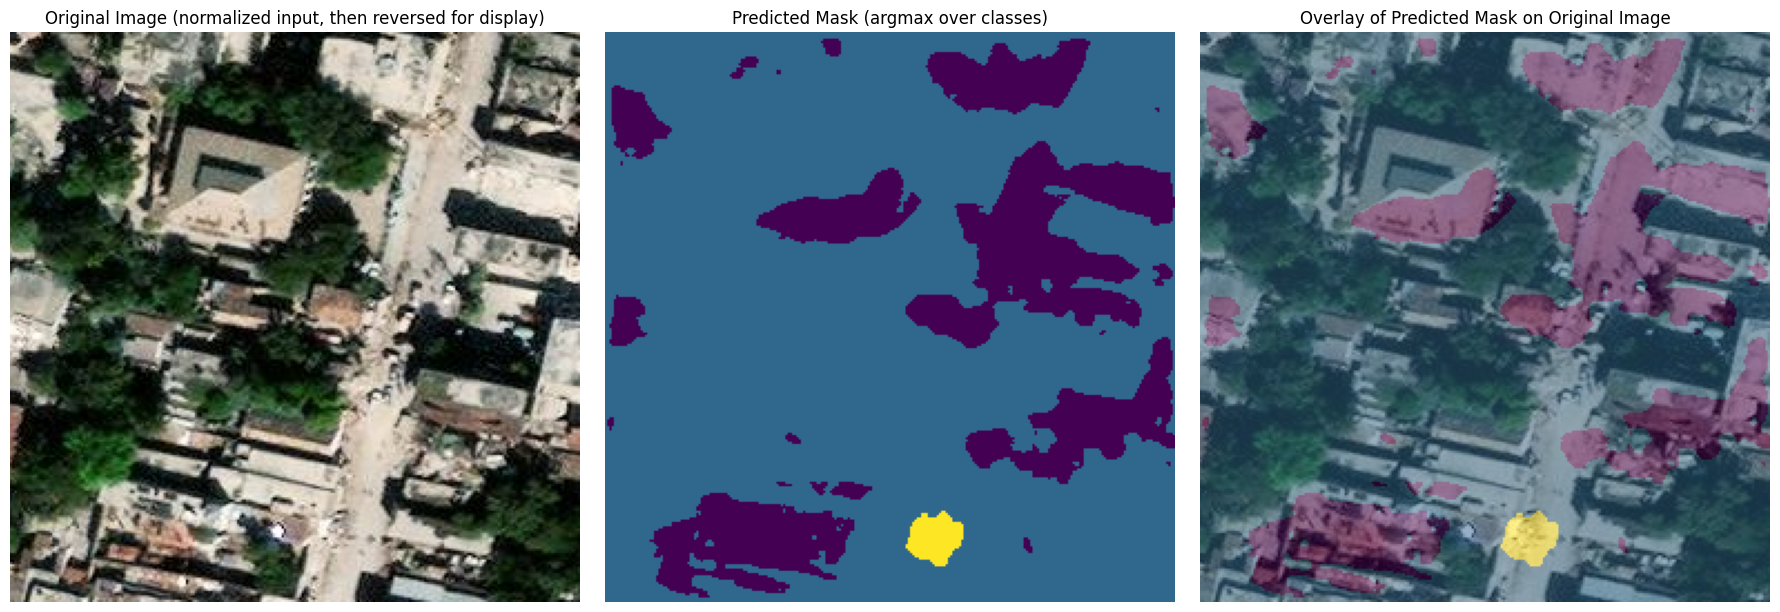

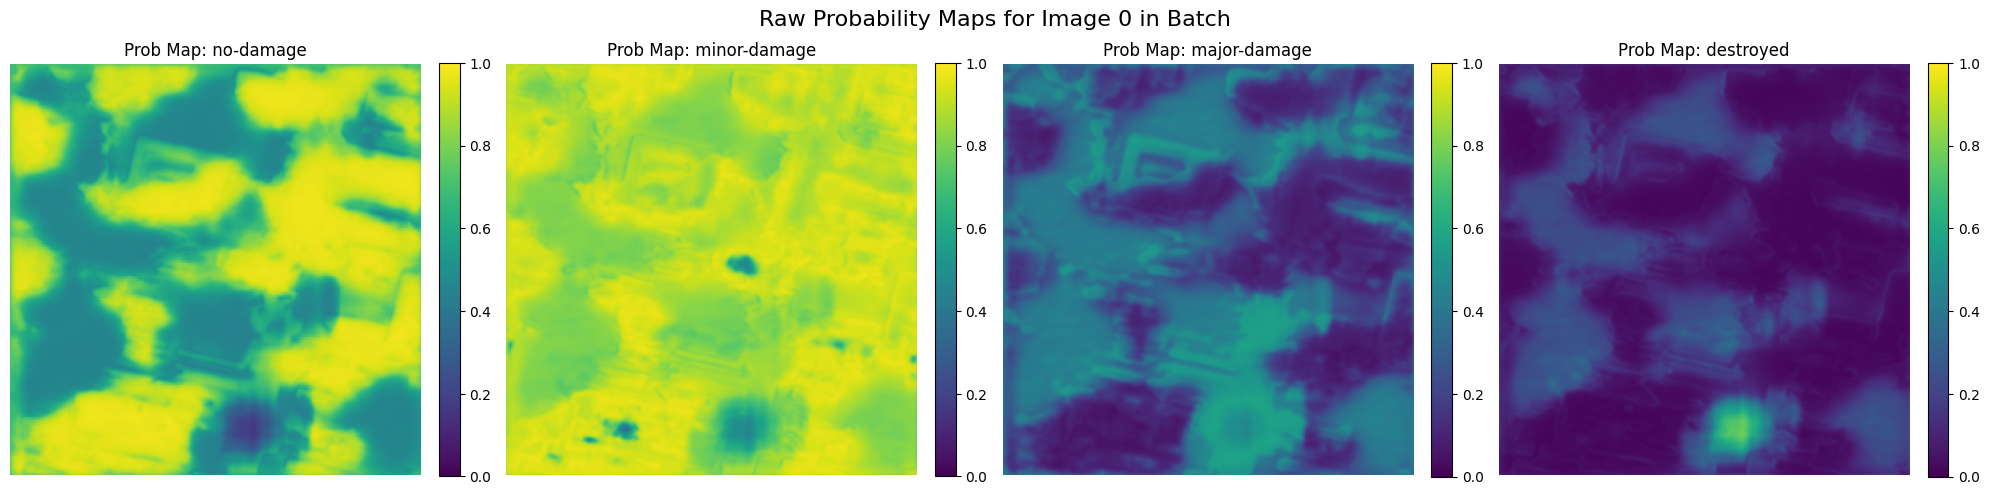

pre-disaster


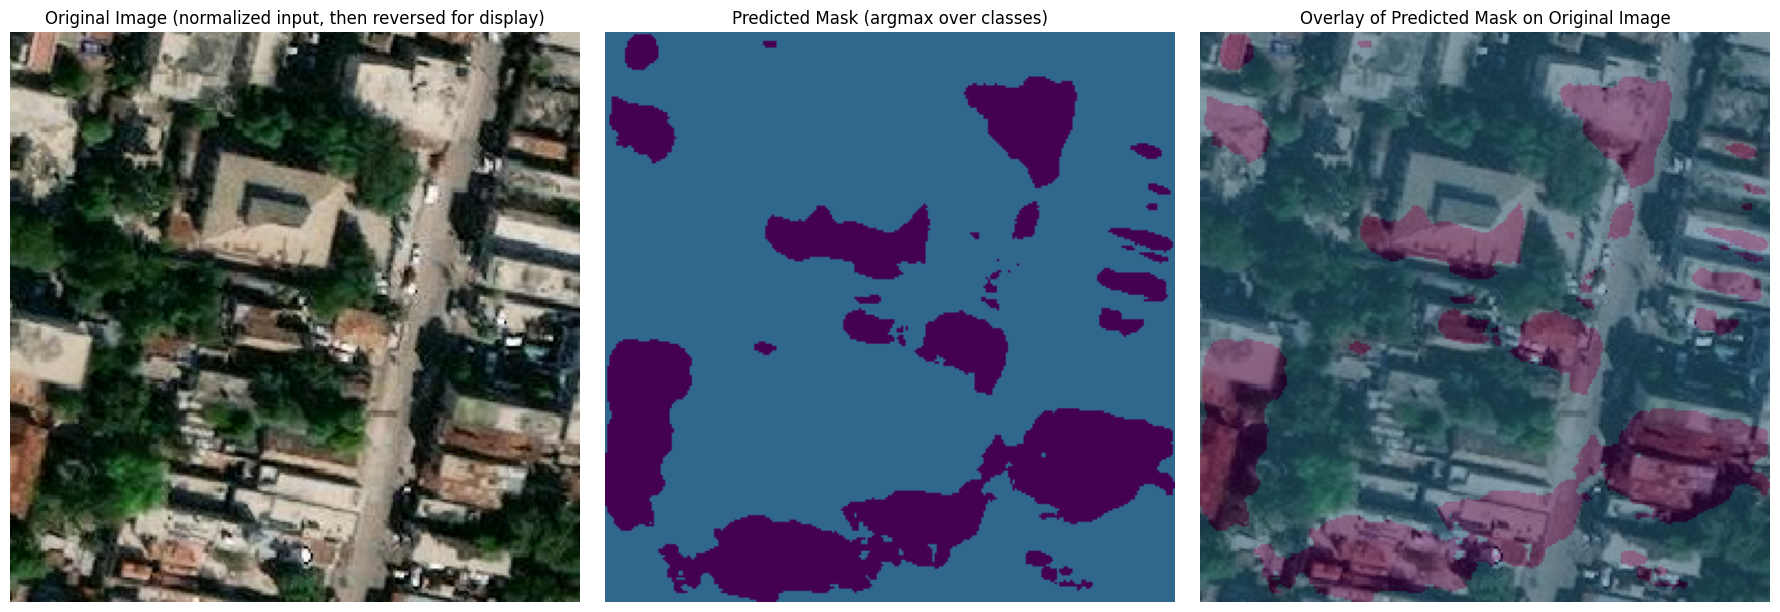

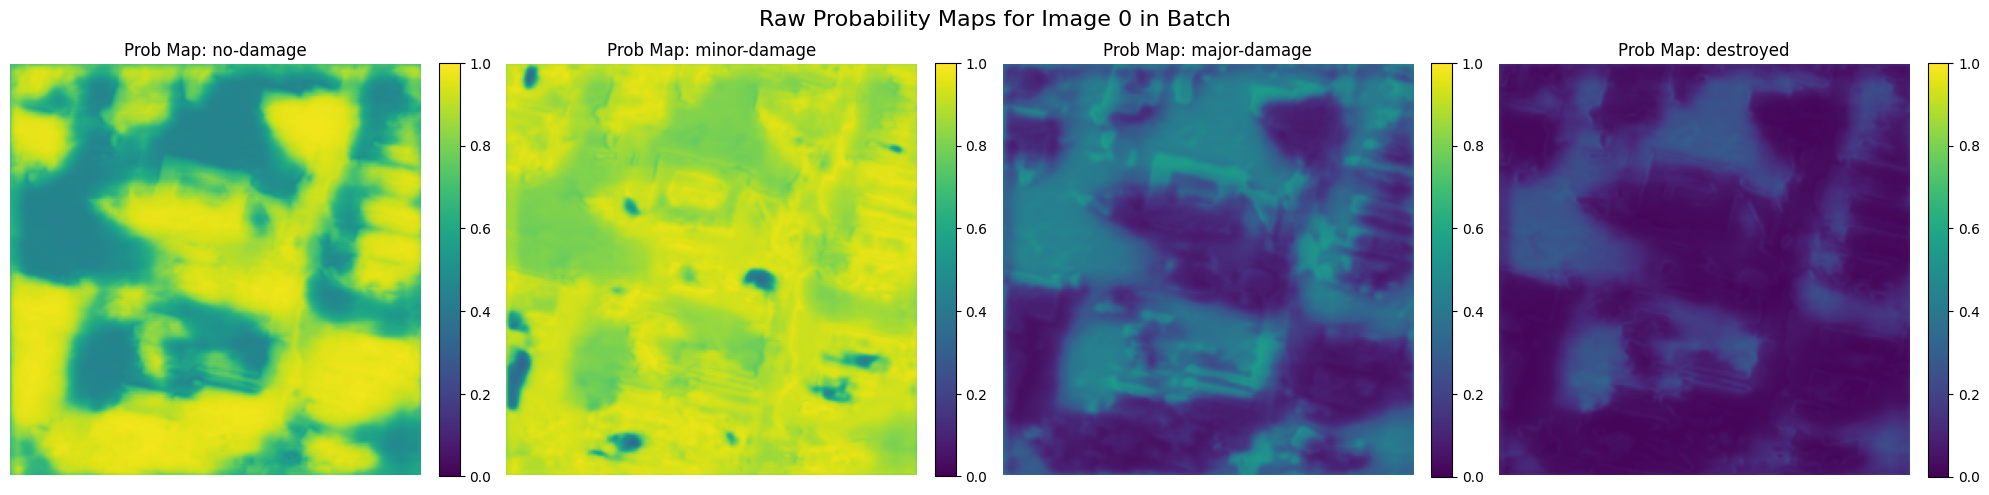

In [ ]:
def preprocess_image_for_model(image_path, image_size=(256, 256)):
    """Apply the same preprocessing used by get_data_loaders."""
    image = load_and_preprocess(image_path)  # (C, H, W), float32 in [0,1] after robust scaling
    
    # Keep RGB channels for a 3-channel model.
    if image.shape[0] >= 3:
        image_pil = Image.fromarray((image[:3].transpose(1, 2, 0) * 255).astype(np.uint8))
    elif image.shape[0] == 1:
        gray = (image.squeeze(0) * 255).astype(np.uint8)
        image_pil = Image.fromarray(gray).convert("RGB")
    else:
        raise ValueError(f"Unsupported image channel count: {image.shape[0]}")

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    infer_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])
    return infer_transform(image_pil).unsqueeze(0)  # (1, 3, H, W)

def display_prediction(image_tensor, pred, idx=0):
    # image_tensor is normalized; reverse_transform expects (C, H, W) tensor on CPU
    img_display = reverse_transform(image_tensor[idx].detach().cpu())
    predicted_mask_np = pred[idx].argmax(dim=0).detach().cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_display)
    axes[0].set_title('Original Image (normalized input, then reversed for display)')
    axes[0].axis('off')

    im = axes[1].imshow(predicted_mask_np, vmin=0, vmax=3)
    axes[1].set_title('Predicted Mask (argmax over classes)')
    axes[1].axis('off')

    #overlay the predicted mask on the original image
    axes[2].imshow(img_display)
    axes[2].imshow(predicted_mask_np, alpha=0.5, vmin=0, vmax=3, cmap='viridis')
    axes[2].set_title('Overlay of Predicted Mask on Original Image')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Pass any image here
image_path_pre_disaster = "/Users/yujiewu/SP/haiti_cropped_smaller/images-pre-disaster/haiti-earthquake_pre_disaster_0228.tif"
image_path = "/Users/yujiewu/SP/haiti_cropped_smaller/images/haiti-earthquake_post_disaster_0228.tif"


# Build inference tensor using the same preprocessing as training/validation
image_tensor = preprocess_image_for_model(image_path).to(device)
image_pre_disaster_tensor = preprocess_image_for_model(image_path_pre_disaster).to(device)
print("Inference tensor shape:", image_tensor.shape)

# Use the currently trained model if available
model.eval()
with torch.no_grad():
    pred = model(image_tensor)
    pred_pre_disaster = model(image_pre_disaster_tensor)

print("post-disaster")

display_prediction(image_tensor, pred, idx=0)
plot_probability_maps(pred, damage_to_idx, image_index=0)
print("pre-disaster")

display_prediction(image_pre_disaster_tensor, pred_pre_disaster, idx=0)
plot_probability_maps(pred_pre_disaster, damage_to_idx, image_index=0)

Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
torch.Size([1, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000001].


(1, 1, 256, 256)


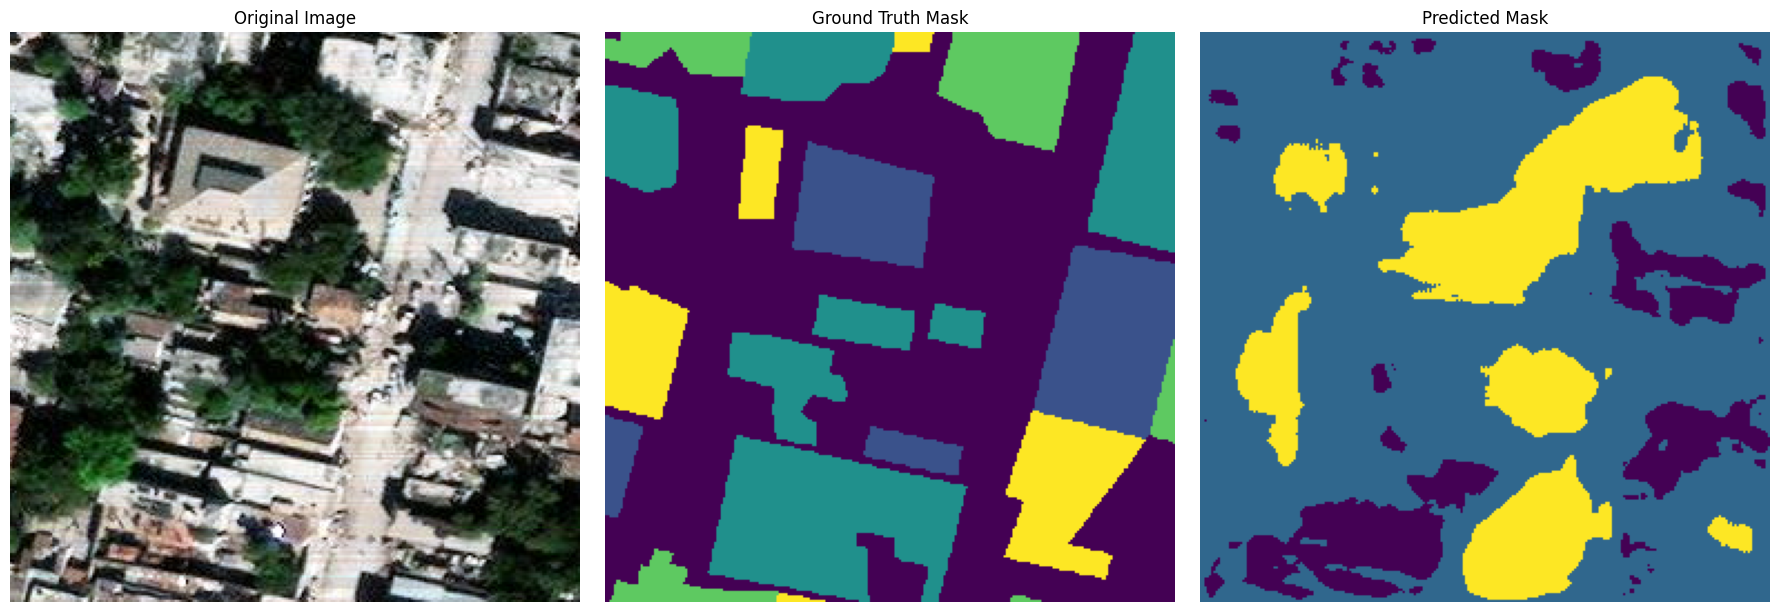

In [23]:
from sklearn.preprocessing import MinMaxScaler

num_class = 4

dataloader = get_data_loaders(batch_size=1)
# Get a sample from the validation dataset
val_dataset = dataloader['val']

data_iter = iter(val_dataset)
first_batch = next(data_iter)
inputs, labels = first_batch

idx = 0
print(inputs.shape)
# Retrieve the original image and label paths for better visualization reference
original_image_path = inputs[idx]
original_label_path = labels[idx]

# Load and preprocess the original image for display (without normalization/tensor conversion)
# The `image_tensor` is already normalized and ready for the model.
# We need the original, denormalized image for visual comparison.
original_image_display = np.transpose(inputs[idx], (1, 2, 0)).numpy()
scaler = MinMaxScaler()

# Fit and transform the data
#display_channels = []
original_image_display = [scaler.fit_transform(original_image_display[x]) for x in range(original_image_display.shape[0])]

# Move image tensor to the correct device for inference
#inputs = inputs.unsqueeze(0).to(device) # Add batch dimension
inputs = inputs.to(device)

model.eval()
#with torch.no_grad():
outputs = model(inputs)
logits = F.softmax(outputs, dim=1)

# Resize logits to the original label size (from the dataset item) for comparison
# and then take argmax to get class predictions
predicted_mask_tensor = torch.nn.functional.interpolate(
    logits,
    size=labels.shape[-2:], # target size is H, W of the ground truth label
    mode="bilinear",
    align_corners=False
).argmax(dim=1).squeeze(0)

predicted_mask_np = predicted_mask_tensor.cpu().numpy()

# Ground truth mask (from the dataset item, already preprocessed and resized)
# Add a channel dimension for masks_to_colorimg to work correctly (expects C, H, W)
ground_truth_mask_np = labels.cpu().numpy()

print(ground_truth_mask_np.shape)
# Convert masks to color images using the defined function
colored_ground_truth = np.transpose(ground_truth_mask_np[0], (1, 2, 0))
colored_prediction = predicted_mask_np#.reshape(1, *predicted_mask_np.shape) # dont Reshape to (1, H, W)

# Plot the original image, ground truth, and prediction
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image_display)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(colored_ground_truth)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(colored_prediction)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [24]:
import torch
import numpy as np

class SegmentationMetrics:
    """
    Accumulates a confusion matrix over the full val set,
    then computes per-class and mean IoU + F1.
    """
    def __init__(self, num_classes: int, class_names: list[str], ignore_index: int = 255):
        self.num_classes = num_classes
        self.class_names = class_names
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        preds:   (B, H, W) — argmax class indices
        targets: (B, H, W) — ground truth class indices
        """
        preds = preds.cpu().numpy().flatten()
        targets = targets.cpu().numpy().flatten()

        # Mask out ignored pixels
        mask = targets != self.ignore_index
        preds, targets = preds[mask], targets[mask]

        # Accumulate into confusion matrix
        indices = self.num_classes * targets + preds
        counts = np.bincount(indices, minlength=self.num_classes ** 2)
        self.confusion_matrix += counts.reshape(self.num_classes, self.num_classes)

    def compute(self) -> dict:
        cm = self.confusion_matrix  # shape: (C, C)

        # Per-class IoU
        tp = np.diag(cm)                          # true positives per class
        fp = cm.sum(axis=0) - tp                  # false positives
        fn = cm.sum(axis=1) - tp                  # false negatives

        iou = tp / (tp + fp + fn + 1e-6)

        # Per-class F1
        precision = tp / (tp + fp + 1e-6)
        recall    = tp / (tp + fn + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        results = {
            "per_class_iou":  dict(zip(self.class_names, iou)),
            "per_class_f1":   dict(zip(self.class_names, f1)),
            "miou":           float(np.mean(iou)),
            "mean_f1":        float(np.mean(f1)),
        }
        return results

In [25]:


dataloader = get_data_loaders()
# Get a sample from the validation dataset
val_dataset = dataloader['val']
metrics_calculator = SegmentationMetrics(num_classes=4, class_names=["no damage", "minor damage", "major damage", "destroyed"], ignore_index=255)
#iterate through entire val dataset and calculate mIoU for each class and mean IoU
ious_per_class = []
mean_ious = []
for inputs, labels in val_dataset:
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        logits = F.softmax(outputs, dim=1)

    predicted_mask_tensor = torch.nn.functional.interpolate(
        logits,
        size=labels.shape[-2:], # target size is H, W of the ground truth label
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)

    labels = remap_labels(labels) # Remap labels to 0,1,2,3 with ignore_index=255 for unclassified

    # Update IoU metrics
    #print(f"Updating IoU metrics for batch with shape: {predicted_mask_tensor.shape} and labels shape: {labels.squeeze(1).shape}")
    #print(f"Unique values in labels: {torch.unique(labels)}")
    metrics_calculator.update(predicted_mask_tensor.cpu(), labels.cpu())

results = metrics_calculator.compute()
print("Per-class IoU:", results["per_class_iou"])
print("Per-class F1:", results["per_class_f1"])
print("Mean IoU:", results["miou"])
print("Mean F1:", results["mean_f1"])

Training images (using pre-undersampled drive): 281
Validation images: 71
TrainingDataset initialized for multi-class (4 damage levels).
TrainingDataset initialized for multi-class (4 damage levels).
Per-class IoU: {'no damage': np.float64(0.3480615683489417), 'minor damage': np.float64(0.23928592503788615), 'major damage': np.float64(0.0), 'destroyed': np.float64(0.24395928187610094)}
Per-class F1: {'no damage': np.float64(0.5163877638310557), 'minor damage': np.float64(0.3861669220326914), 'major damage': np.float64(0.0), 'destroyed': np.float64(0.3922298643004024)}
Mean IoU: 0.2078266938157322
Mean F1: 0.3236961375410373
